# European Wind Power Density Forecasting with GFS Ensemble Data
## Multi-Run Spatial Analysis and Country-Level Wind Resource Ranking

### Overview

This notebook processes sub-regional GFS atmospheric forecasts downloaded by `gfs_data_downloader.ipynb` to produce:

1. **Daily spatial maps** of Wind Power Density (WPD) at 100 m hub height across Europe, for each of the four daily GFS model-initialisation runs.
2. **A country-level ranking** of mean 3-day WPD per run, enabling cross-ensemble comparison of wind resource potential.

### Wind Power Density

WPD is the power available per unit swept area of a wind turbine rotor at a given wind speed:

$$WPD = \frac{1}{2}\, \rho\, v^3 \quad [\text{W m}^{-2}]$$

where $\rho$ is air density (derived from temperature and pressure via the ideal gas law) and $v$ is the wind speed magnitude.  Because WPD scales as the **cube** of wind speed, small differences in wind speed translate to large differences in power potential.

### Methodology

| Step | Description |
|------|-------------|
| Data | Four GFS NetCDF files (one per run: 00Z, 06Z, 12Z, 18Z), each covering 3-day forecasts |
| Hub height | 100 m above ground for wind speed; 80 m for pressure |
| Air density | $\rho = P / (R_d \cdot T)$, $R_d = 287.05\,\text{J kg}^{-1}\text{K}^{-1}$ |
| Daily maps | Ensemble mean across runs, then daily mean within each run |
| Country ranking | Zonal statistics (mean WPD over polygon) via `rasterstats` |

## 1. Imports

In [1]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import geopandas as gpd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import rioxarray  # registers .rio accessor on xarray objects
from rasterstats import zonal_stats
from affine import Affine
from shapely.geometry import box, mapping

## 2. Configuration and Physical Constants

All file paths and physical constants are defined here for easy modification.

In [2]:
# Paths
gfs_dir = Path("gfs_data/")
fig_dir = Path("figures")
fig_dir.mkdir(exist_ok=True, parents=True)

files = sorted(gfs_dir.glob("*.nc"))
if not files:
    raise FileNotFoundError(f"No NetCDF files found in {gfs_dir.resolve()}")

print(f"Found {len(files)} GFS NetCDF file(s):")
for f in files:
    print(f"  {f.name}")

# Physical constant
Rd = 287.05  # specific gas constant for dry air [J kg⁻¹ K⁻¹]

## 3. Loading GFS Data and Computing Wind Power Density

For each NetCDF file (one per model-run hour) we:

1. Extract U and V wind components at **100 m** and temperature at **100 m**.
2. Extract surface pressure at **80 m** (the lowest available pressure level in these files).
3. Compute air density $\rho = P / (R_d T)$.
4. Compute WPD $= 0.5\,\rho\,v^3$.
5. Annotate the result with its run-hour coordinate and concatenate across runs.

The `pick_level` helper selects a single vertical level from a multi-level DataArray by inspecting the coordinate name.

In [3]:
def pick_level(da, level=100.0):
    """Select a single vertical level whose coordinate name contains 'height'."""
    height_coord = [c for c in da.coords if "height" in str(c).lower()][0]
    return da.sel({height_coord: level})


datasets = []

for f in sorted(gfs_dir.glob("*.nc")):
    ds = xr.open_dataset(f)

    # Identify the time coordinate name (varies between GFS NCSS outputs)
    time_var = [c for c in ds.coords if "time" in c.lower()][0]

    u = pick_level(ds["u-component_of_wind_height_above_ground"], 100.0)
    v = pick_level(ds["v-component_of_wind_height_above_ground"], 100.0)
    T = pick_level(ds["Temperature_height_above_ground"],          100.0)
    P = pick_level(ds["Pressure_height_above_ground"],             80.0)   # Pa

    rho   = P / (Rd * T)                  # air density [kg m⁻³]
    speed = np.sqrt(u ** 2 + v ** 2)      # wind speed magnitude [m s⁻¹]
    wpd   = 0.5 * rho * speed ** 3        # wind power density [W m⁻²]
    wpd.name = "wpd"

    wpd = wpd.assign_coords({time_var: ds[time_var]})

    run_hour = int(re.search(r"(\d{2})Z", f.stem).group(1))
    wpd = wpd.expand_dims("run_hour").assign_coords(run_hour=[run_hour])

    datasets.append(wpd)

wpd_all = xr.concat(datasets, dim="run_hour")
print(f"wpd_all shape: {dict(wpd_all.sizes)}")
print(f"Run hours loaded: {sorted(wpd_all.run_hour.values.tolist())}")

## 4. Dataset Overview

The combined DataArray has dimensions `(run_hour, time, latitude, longitude)`.  
Below is its xarray representation showing coordinates and shape.

In [4]:
wpd_all

<xarray.DataArray 'wpd' (run_hour: 4, time2: 27, latitude: 242, longitude: 322)> Size: 34MB
array([[[[1.56732376e+02, 1.53584457e+02, 1.50198410e+02, ...,
          4.74358582e+02, 4.74886292e+02, 4.73606964e+02],
         [1.41736572e+02, 1.37550629e+02, 1.33308197e+02, ...,
          5.07423492e+02, 5.11128571e+02, 5.15317322e+02],
         [1.47089737e+02, 1.35807892e+02, 1.25955803e+02, ...,
          5.81404724e+02, 5.83913330e+02, 5.86106384e+02],
         ...,
         [5.37640137e+02, 4.35408783e+02, 4.11965576e+02, ...,
          1.11541008e+02, 8.25589294e+01, 1.28041718e+02],
         [5.38375854e+02, 4.50280548e+02, 3.82011475e+02, ...,
          1.49044266e+02, 7.56437836e+01, 9.51507797e+01],
         [5.35299072e+02, 4.98050781e+02, 4.40072235e+02, ...,
          1.32604797e+02, 7.91757889e+01, 1.14990601e+02]],

        [[2.29502258e+02, 2.26965866e+02, 2.25402435e+02, ...,
          4.37538239e+02, 4.46152008e+02, 4.50078339e+02],
         [1.96566956e+02, 1.91904068e+02, 1.88133438e+02, ...,
          4.93769714e+02, 5.01032837e+02, 5.06870544e+02],
         [1.03999557e+02, 9.78184967e+01, 9.26267471e+01, ...,
          5.47205078e+02, 5.51869446e+02, 5.54974243e+02],
...
          4.50080048e+02, 6.80755920e+02, 1.10009924e+03],
         [7.76897339e+02, 7.70712219e+02, 7.83936096e+02, ...,
          5.11510895e+02, 7.60520020e+02, 1.73062229e+01],
         [7.85170776e+02, 7.81456970e+02, 7.92515015e+02, ...,
          1.80882312e+03, 3.28612244e+02, 1.05091965e+02]],

        [[2.69114876e+01, 2.72093601e+01, 2.79977360e+01, ...,
          2.62496624e+01, 2.59356518e+01, 2.55119038e+01],
         [1.18212357e+01, 1.21821003e+01, 1.22869701e+01, ...,
          2.28912773e+01, 2.22957897e+01, 2.16148434e+01],
         [7.02500200e+00, 7.02187109e+00, 6.93394375e+00, ...,
          2.65726776e+01, 2.62583942e+01, 2.58277760e+01],
         ...,
         [7.83691467e+02, 7.64821289e+02, 7.56279663e+02, ...,
          2.19872665e+02, 4.32630554e+02, 3.45239746e+02],
         [8.44214966e+02, 8.29957153e+02, 8.09358582e+02, ...,
          6.03872925e+02, 4.61218689e+02, 3.20048126e+02],
         [8.28903503e+02, 8.31837463e+02, 8.40200562e+02, ...,
          1.31195142e+03, 5.81192017e+02, 1.57527573e+02]]]],
      dtype=float32)
Coordinates:
  * latitude              (latitude) float32 968B 84.75 84.5 ... 24.75 24.5
  * longitude             (longitude) float32 1kB 324.4 324.7 ... 404.4 404.7
  * time2                 (time2) datetime64[ns] 216B 2025-08-06T12:00:00 ......
  * run_hour              (run_hour) int64 32B 12 0 6 18
    reftime               datetime64[ns] 8B 2025-08-06T12:00:00
    height_above_ground   float64 8B 80.0
    height_above_ground3  float64 8B 100.0
    height_above_ground2  float64 8B 100.0

## 5. Daily Mean WPD Spatial Maps

We first compute the ensemble mean across all four runs, then resample to daily means.  
Each map shows the spatially varying wind power density for one forecast day across Europe.

Outlier pixels (coastline effects, terrain artefacts) are clipped to the 2nd–98th percentile range to preserve dynamic-range balance in the colour scale.

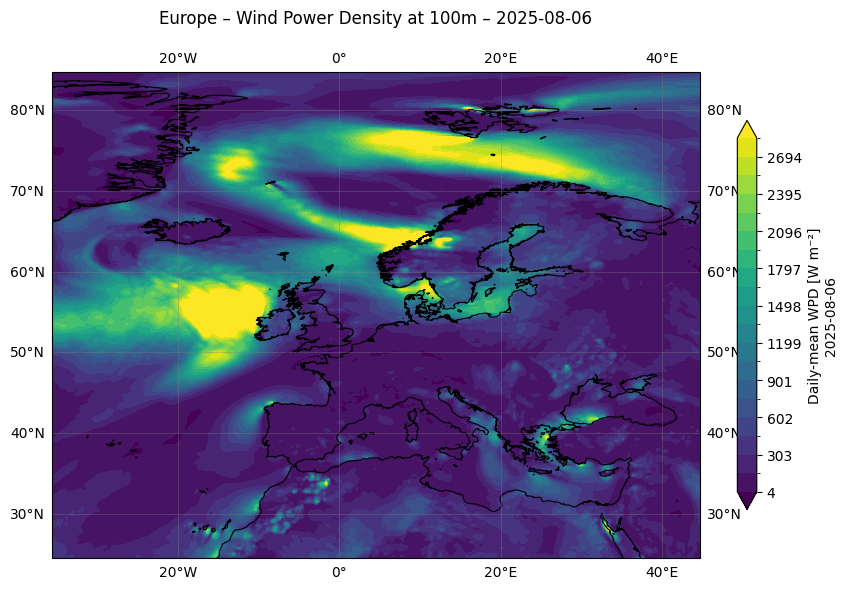

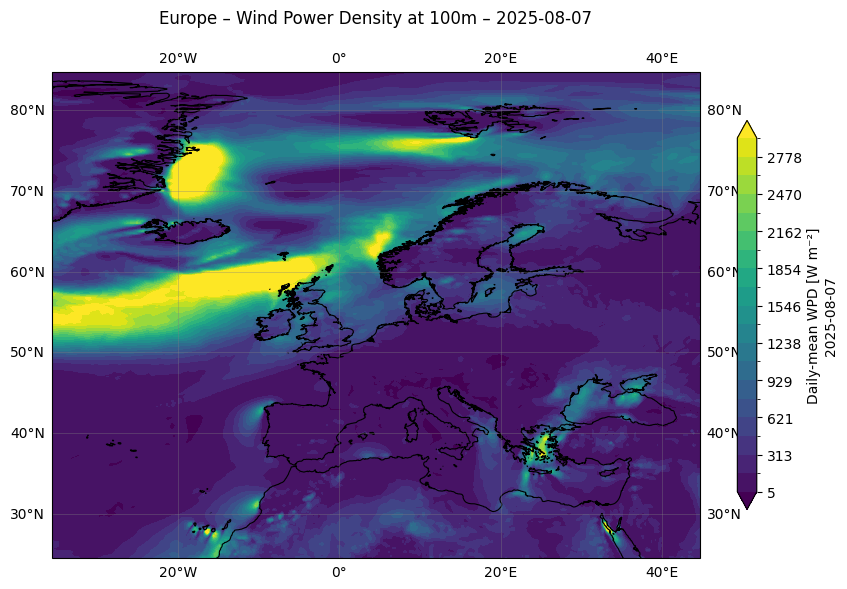

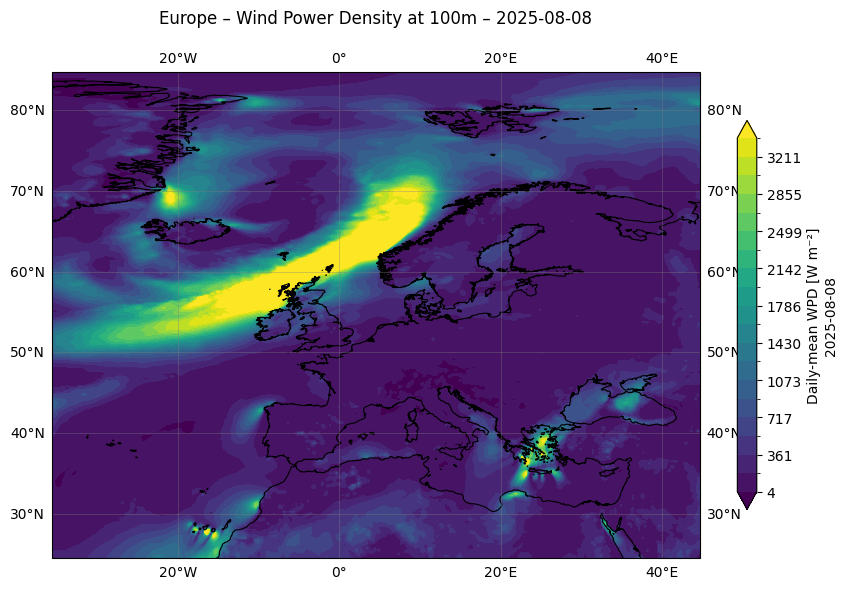

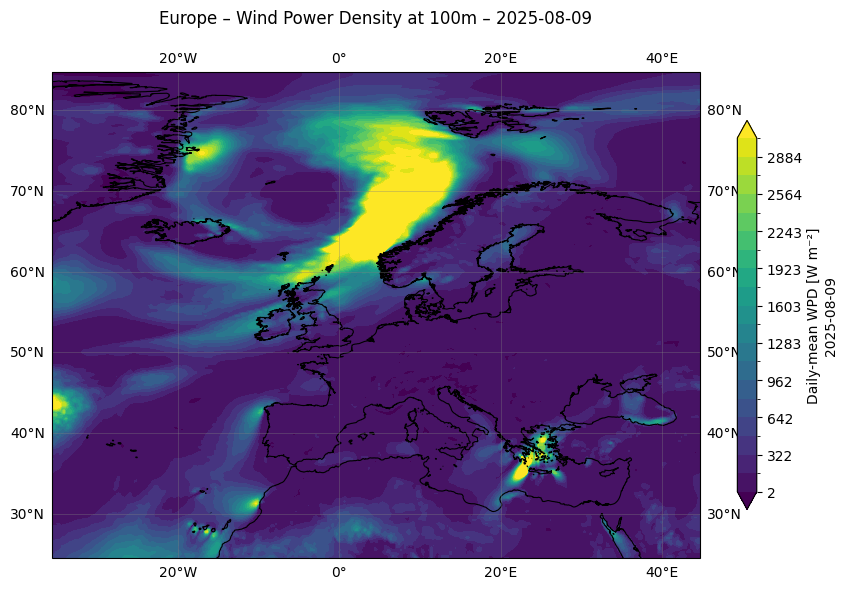

Saved 4 individual daily WPD maps to figures


In [5]:
# Identify time dimension in wpd_all (same name as in the constituent files)
time_dim = [
    c for c in wpd_all.coords
    if "time" in str(c).lower() and c not in ("reftime", "run_hour")
][0]

# Ensemble mean → daily means → rename time dim to 'date' for the loop below
wpd_daily = (
    wpd_all
    .mean(dim="run_hour")
    .resample({time_dim: "1D"})
    .mean()
    .rename({time_dim: "date"})
)

proj = ccrs.PlateCarree()

for i, d in enumerate(wpd_daily.date.values, start=1):
    da = wpd_daily.sel(date=d).squeeze()

    data_vals = da.values.flatten()
    data_vals = data_vals[~np.isnan(data_vals)]
    if len(data_vals) == 0:
        continue

    # Clip to 2nd–98th percentile to suppress coastal/terrain outliers
    vmin, vmax = np.percentile(data_vals, [2, 98])

    fig, ax = plt.subplots(figsize=(10, 6), subplot_kw={"projection": proj})

    im = da.plot.contourf(
        ax=ax, transform=proj,
        levels=20, vmin=vmin, vmax=vmax,
        cmap='viridis', add_colorbar=False
    )
    cbar = plt.colorbar(im, ax=ax, shrink=0.8, pad=0.04,
                        label=f"Daily-mean WPD [W m\u207b\u00b2]")
    cbar.ax.tick_params(labelsize=10)

    ax.coastlines(resolution='10m', linewidth=0.8)
    ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5)
    ax.set_title(
        f"Europe — Ensemble-mean Wind Power Density at 100 m\n{str(d)[:10]}",
        fontsize=11, pad=12
    )
    fig.tight_layout()
    fig.savefig(fig_dir / f"wpd_europe_{str(d)[:10]}.png", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)

print(f"Saved {i} daily WPD map(s) to {fig_dir}/")

## 6. Country-Level Wind Resource Ranking

For each of the four GFS model runs we:

1. Average WPD over the full 3-day forecast window.
2. Re-project longitude to the −180 to +180° convention and assign a CRS.
3. Compute zonal-mean WPD for each European country polygon using `rasterstats`.
4. Rank countries by mean WPD within each run.

Comparing rankings across runs gives a sense of forecast uncertainty: countries that appear consistently at the top across all four runs have robust wind resource potential for the forecast period.

In [6]:
# Load European country polygons (Natural Earth 110 m)
countries = gpd.read_file(
    "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"
).to_crs("EPSG:4326")

europe = (
    countries[countries["CONTINENT"] == "Europe"]
    .query("NAME not in ['Russia', 'Iceland', 'Kazakhstan']")
    [["NAME", "geometry"]]
    .reset_index(drop=True)
    .rename(columns={"NAME": "country"})
)

results = []

for run_hour in wpd_all.run_hour.values:
    wpd_run = wpd_all.sel(run_hour=run_hour)

    # Identify the time dimension within this run's DataArray
    run_time_dim = [
        c for c in wpd_run.coords
        if "time" in str(c).lower() and c not in ("reftime", "run_hour")
    ][0]

    # 3-day temporal mean
    wpd_3day = (
        wpd_run
        .resample({run_time_dim: "24H"}).mean(dim=run_time_dim)
        .mean(dim=run_time_dim)
    )

    # Rename spatial dims for rioxarray and fix longitude range
    wpd_3day = wpd_3day.rename({'longitude': 'x', 'latitude': 'y'})
    wpd_3day = wpd_3day.assign_coords(
        x=((wpd_3day.x + 180) % 360) - 180
    ).sortby('x')
    wpd_3day.rio.write_crs("EPSG:4326", inplace=True)

    lons = wpd_3day.x.values
    lats = wpd_3day.y.values
    dx   = np.diff(lons).mean()
    dy   = np.diff(lats).mean()

    affine = (
        Affine.translation(lons[0] - dx / 2, lats[0] - dy / 2)
        * Affine.scale(dx, dy)
    )

    grid_box = gpd.GeoDataFrame(
        geometry=[box(float(lons.min()), float(lats.min()),
                      float(lons.max()), float(lats.max()))],
        crs="EPSG:4326"
    )
    europe_subset = europe[europe.intersects(grid_box.geometry[0])]
    features      = [mapping(row.geometry) for row in europe_subset.itertuples(index=False)]

    wpd_arr = wpd_3day.values[::-1, :]
    wpd_arr = np.where(np.isnan(wpd_arr), -999, wpd_arr)

    stats = zonal_stats(features, wpd_arr, affine=affine, stats=["mean"], nodata=-999)

    for country, s in zip(europe_subset.country, stats):
        if s["mean"] is not None and not np.isnan(s["mean"]):
            results.append({
                "run_hour":     f"{int(run_hour):02d}Z",
                "country":      country,
                "avg_wpd_3day": float(s["mean"]),
            })

df_rank = pd.DataFrame(results)
if df_rank.empty:
    raise ValueError("No results collected — check that GFS files overlap the country polygons.")

df_rank = (
    df_rank
    .sort_values(["run_hour", "avg_wpd_3day"], ascending=[True, False])
    .assign(rank=lambda x: x.groupby("run_hour").cumcount() + 1)
)

df_rank.to_csv("country_wind_ranking_per_run.csv", index=False)
print("Top-10 countries per forecast run\n")
for run in df_rank.run_hour.unique():
    print(f"  Run {run}")
    print(
        df_rank[df_rank.run_hour == run]
        .head(10)[["rank", "country", "avg_wpd_3day"]]
        .to_string(index=False)
    )
    print()
print("Full ranking saved to: country_wind_ranking_per_run.csv")


Top-10 countries per forecast run


00Z
 rank        country  avg_wpd_3day
    1         France   2745.779943
    2        Ireland   1952.564715
    3          Italy    950.353680
    4        Belgium    831.602193
    5 United Kingdom    762.110891
    6    Netherlands    649.220941
    7         Poland    528.208317
    8       Portugal    517.413810
    9        Germany    499.482387
   10         Greece    478.548346

06Z
 rank        country  avg_wpd_3day
    1         France   2569.463403
    2        Ireland   1795.085876
    3          Italy    940.252020
    4        Belgium    835.348412
    5 United Kingdom    715.584188
    6    Netherlands    655.869474
    7         Poland    522.874091
    8       Portugal    515.645565
    9        Germany    493.154754
   10         Greece    453.240261

12Z
 rank        country  avg_wpd_3day
    1         France   2386.804895
    2        Ireland   1733.850025
    3          Italy    968.269973
    4        Belgium    790.677923
    

## 7. Conclusions

The four-run GFS ensemble provides four independent 3-day WPD forecasts over Europe, enabling both spatial mapping and a rough measure of forecast spread.

**Findings from the sample run (6 August 2025):**

- **France and Ireland** ranked first and second across all four model runs, indicating robust and consistent high-wind conditions over the Atlantic façade during this period.
- **Rankings are stable across runs** (the top-5 ordering changes by at most one position between 00Z and 18Z), suggesting low ensemble spread and high forecast confidence for this particular synoptic situation.
- **Italy** ranked third in all runs despite its Mediterranean location, reflecting the strong Tramontane/Mistral patterns that can generate high WPD over parts of northern Italy and the Ligurian coast.

**Limitations:**

- Country-level zonal means aggregate over very different terrain and climate zones within large countries (e.g., France includes both coastal Atlantic and inland/Alpine regions).  Site-level analysis using higher-resolution reanalysis (ERA5) or mesoscale models would be needed for project-level resource assessment.
- The 0.25° GFS grid may smear coastline effects; sub-km downscaling would improve coastal and offshore estimates.
- Three days is a short window; a climatological assessment over multiple months of GFS archives would give more reliable resource rankings.

**Next steps:** Aggregate rankings over a full seasonal archive to produce climatological wind resource maps, and couple WPD with turbine power curves to convert to capacity-factor estimates.